In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append("..")
from sklearn.decomposition import NMF

from Src.data_modules import *

# Load data

In [4]:
nb_sets = 2
nb_channels = 5

multitaper_data = get_windowed_multitaper_data(nb_sets=nb_sets, nb_channels=nb_channels, type="test")

Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Last window removed for channel 0 in set 1
Iteration 7/10
Last window removed for channel 1 in set 1
Iteration 8/10
Last window removed for channel 2 in set 1
Iteration 9/10
Last window removed for channel 3 in set 1
Iteration 10/10
Last window removed for channel 4 in set 1


In [5]:
# Data treatment
all_windows = [window for set_data in multitaper_data for channel_data in set_data for window in channel_data]
all_windows = np.array(all_windows)
all_windows_2d = np.squeeze(all_windows) # Remove last dimension not used
all_windows_2d = [[x if x >= 0 else 0 for x in arr] for arr in all_windows_2d] # Non negative variables

In [6]:
len(all_windows_2d)

112615

In [11]:
len(all_windows_2d[0])

62

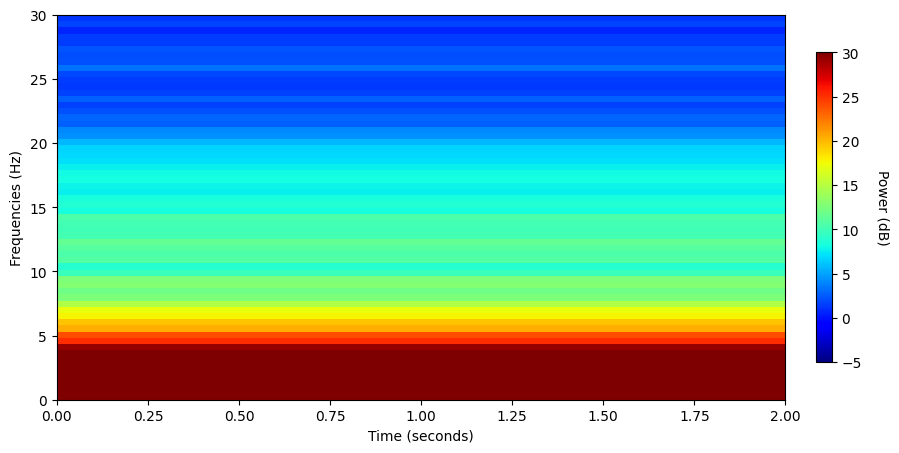

In [13]:
fig, ax = plt.subplots(figsize=(10,5))

cax = ax.imshow(multitaper_data[0][0][0], aspect='auto', vmin=-5, vmax=30, cmap="jet", extent=[0, 2, 30, 0])

cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Power (dB)', rotation=270, labelpad=20)

ax.invert_yaxis()
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Frequencies (Hz)")

plt.show()

# NMF construction

In [5]:
# Initialiser un modèle NMF
n_components = 4  # Nombre de composantes latentes
model = NMF(n_components=n_components, init='random', random_state=42)

# Ajuster le modèle sur les données
W = model.fit_transform(all_windows_2d)  # Matrice W (caractéristiques latentes)
H = model.components_ # Matrice H (poids des caractéristiques)

In [6]:
# Erreur de reconstruction
reconstruction_error = model.reconstruction_err_

# Norme Frobenius de la matrice originale
original_norm = np.linalg.norm(all_windows_2d, ord='fro')

# Ratio de reconstruction
reconstruction_ratio = 1 - (reconstruction_error / original_norm)

print(f"Erreur de reconstruction : {reconstruction_error}")
print(f"Ratio de reconstruction : {reconstruction_ratio}")

Erreur de reconstruction : 4951.118194399334
Ratio de reconstruction : 0.9309121220999568


# NMF analysis

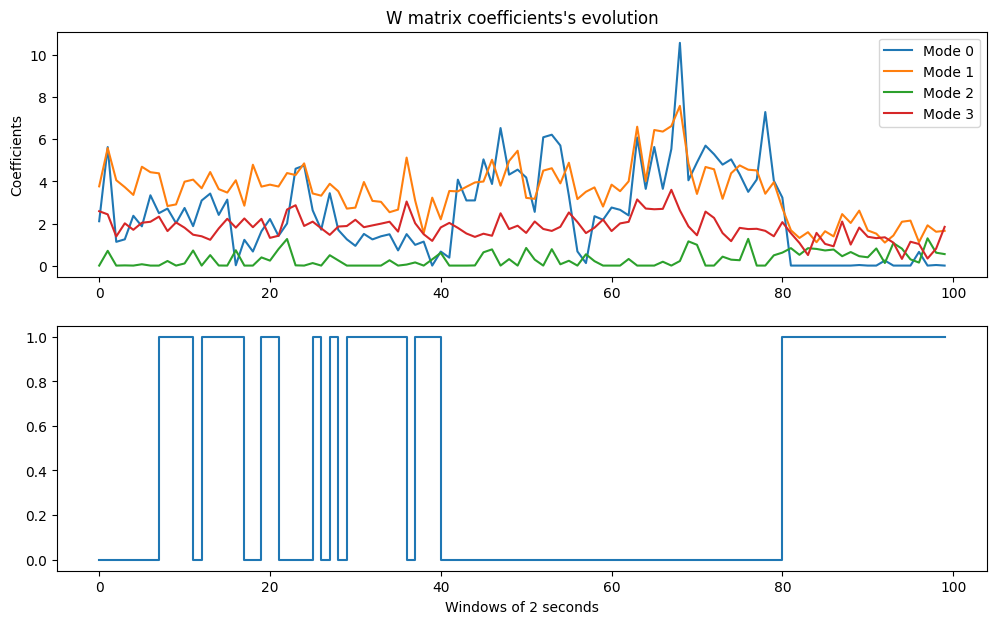

In [7]:
fig, axs = plt.subplots(2,1, figsize=(12,7))

axs[0].plot(W[:100])
axs[0].set_ylabel("Coefficients")
axs[0].set_title("W matrix coefficients's evolution")
axs[0].legend(["Mode {}".format(i) for i in range(n_components)])

_, target_data = load_train_data(set=0)
axs[1].step(range(len(target_data[0][:100])), target_data[0][:100])
axs[1].set_xlabel("Windows of 2 seconds")

plt.show()

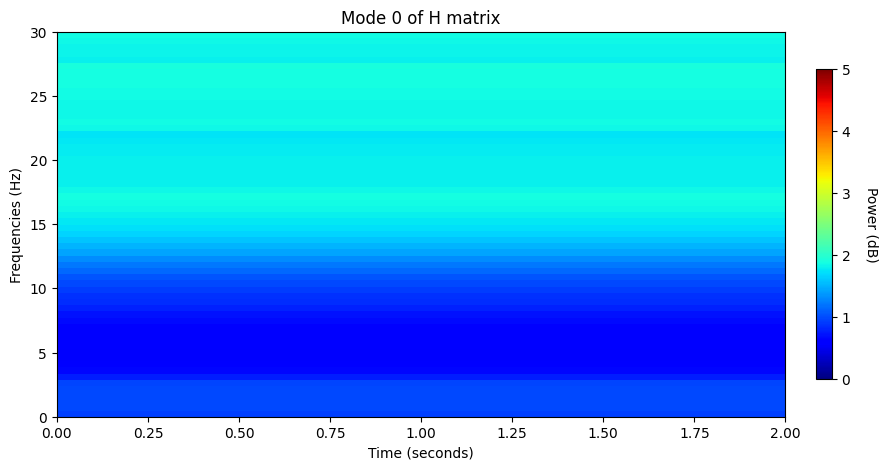

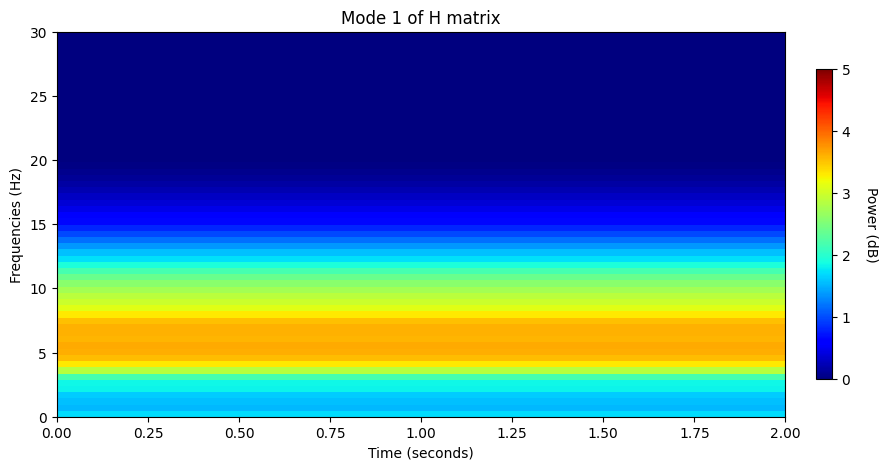

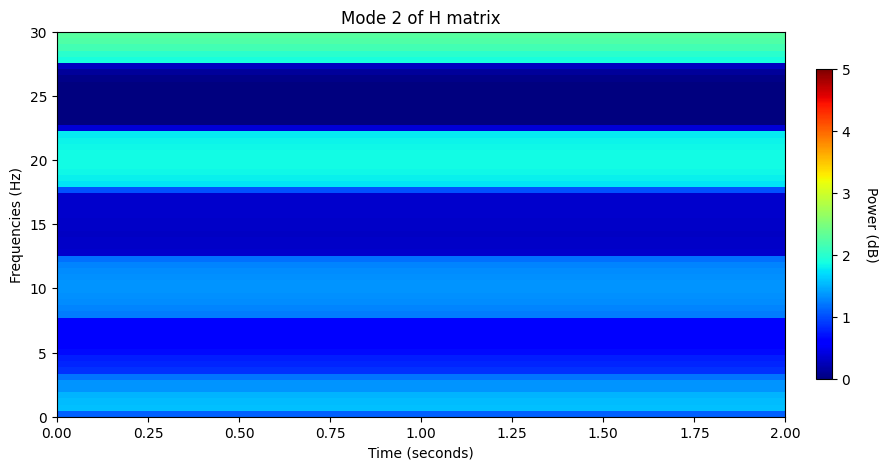

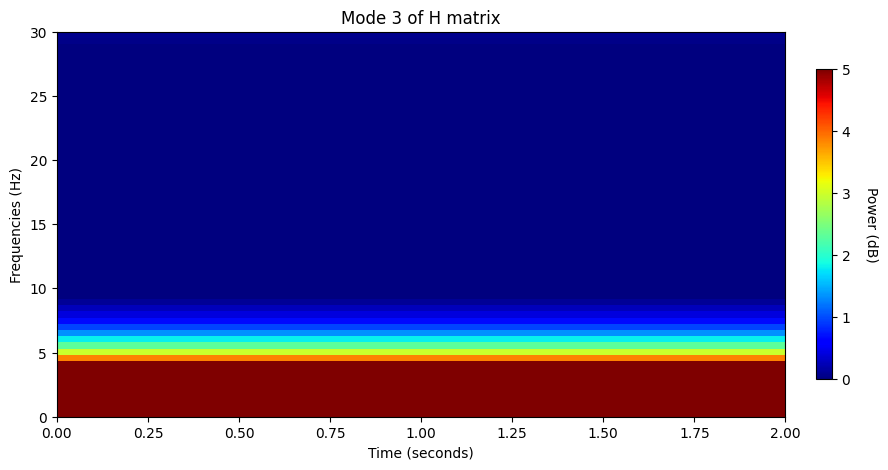

In [8]:
for i in range(n_components):
    fig, ax = plt.subplots(figsize=(10,5))

    cax = ax.imshow(np.reshape(H[i,:], (62,1)), aspect='auto', vmin=0, vmax=5, cmap="jet", extent=[0, 2, 30, 0])

    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Power (dB)', rotation=270, labelpad=20)

    ax.invert_yaxis()
    ax.set_title("Mode {} of H matrix".format(i))
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Frequencies (Hz)")

    plt.show()

# NMF Data creation for other models

In [6]:
data_model = pd.DataFrame(W, columns=["mode_{}".format(i) for i in range(4)])

In [ ]:
# Paramètres
fs_original = 250  # Fréquence d'échantillonnage initiale (250 Hz)
fs_target = 0.5    # Fréquence cible (1 échantillon toutes les 2 secondes => 0.5 Hz)
window_size = int(fs_original * 2)  # Taille de la fenêtre de 2 secondes (250 * 2 = 500 échantillons)

resampled_data = []
resampled_target = []

for s in range(4): # 4 sets
    train_data, target_data = load_train_data(set=s)
    resampled_set = []
    for c in range(5): # 5 Channels
        # Rééchantillonnage par moyenne
        num_windows = len(train_data[c]) // window_size  # Nombre de fenêtres

        for i in range(num_windows):
            start_idx = i * window_size
            end_idx = (i + 1) * window_size
            window = train_data[c][start_idx:end_idx]
            resampled_data.append(np.mean(window))  # Moyenne de la fenêtre

        resampled_target += list(target_data[c])


data_model["amplitude"] = resampled_data
data_model["target"] = resampled_target


In [10]:
# Paramètres
fs_original = 250  # Fréquence d'échantillonnage initiale (250 Hz)
fs_target = 0.5    # Fréquence cible (1 échantillon toutes les 2 secondes => 0.5 Hz)
window_size = int(fs_original * 2)  # Taille de la fenêtre de 2 secondes (250 * 2 = 500 échantillons)

resampled_data = []

for s in range(2): # 2 sets
    test_data = load_test_data(set=s)
    for c in range(5): # 5 Channels
        # Rééchantillonnage par moyenne
        num_windows = len(test_data[c]) // window_size  # Nombre de fenêtres

        for i in range(num_windows):
            start_idx = i * window_size
            end_idx = (i + 1) * window_size
            window = test_data[c][start_idx:end_idx]
            resampled_data.append(np.mean(window))  # Moyenne de la fenêtre

data_model["amplitude"] = resampled_data

In [11]:
data_model.to_csv("test_data_model.csv", sep=";")